# Determining best 3D plotting box aspect

Should it be using the output data range?

## Conclusions

Since the function we're examining here is to be used to plot field solutions, which are well-behaved, we shouldn't have to worry about singularities. In this case, setting the limits using the data range is good, and we incorporated it into the code.

In [132]:
import numpy as np
import matplotlib.pyplot as plt
from slab import SlabExact

%matplotlib widget
plt.style.use('dark_background')

In [2]:
A = SlabExact(symmetric=True)

w = .5
s = 0
amp = .6

Lx = -w + s
Rx = w + s

def quadratic_piecewise(x):
    conds = [(x<Lx), ((Lx<=x)*(x<=Rx)), (x>Rx)]
    funcs = [0, lambda x: amp * (1 - ((x-s)/w)**2), 0]
    return np.piecewise(x, conds, funcs)

def quadratic_piecewise2d(x, zs=None, wavenumber=A.K0):
    conds = [(x<Lx), ((Lx<=x)*(x<=Rx)), (x>Rx)]
    funcs = [0, lambda x: amp * (1 - ((x-s)/w)**2), 0]
    fx = np.piecewise(x, conds, funcs)
    fz = np.exp(1j * wavenumber * zs)
    return np.outer(fz, fx)

f0 = quadratic_piecewise

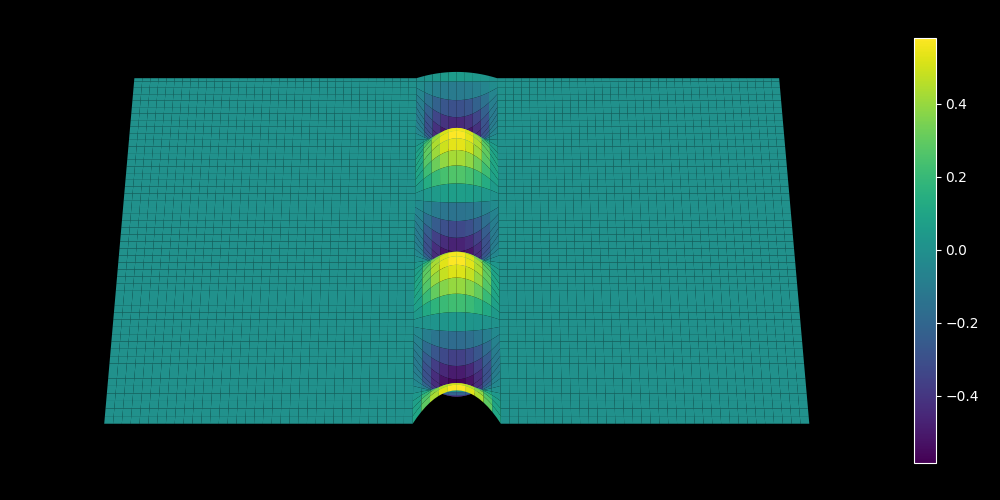

In [3]:
A.plot_field_2d_surface(quadratic_piecewise2d, colorbar=True);

In [127]:
def plot_field_2d_surface(
    self,
    F,
    *F_args,
    xs=None,
    zs=None,
    zmin=0,
    zmax=5,
    zref=100,
    part="real",
    product_func=True,
    show_axis=False,
    figsize=(10, 5),
    rectangle=None,
    cmap="viridis",
    azim=-90,
    elev=55,
    roll=0,
    zoom=2,
    rstride=2,
    cstride=2,
    z_lim_factor=1,
    truncate=False,
    max_height=1e7,
    min_height=-1e7,
    colorbar=False,
    pad=0.15,
    shrink=0.85,
    colorbar_frac=0.15,
    anchor=(0.5, 0.5),
    orient="vertical",
    **surfaceargs,
):
    """Plot field F as 3d surface plot.

    If no xs are provided, plots entire region defined by SlabExact class.

    Note that by default we avoid applying meshgrid to xs and zs until after calling
    function. Since field is a product of single function of xs and
    single function of zs it would be wasteful to call it on the meshed
    arrays.  However if we want to plot a non-product function, the user can
    pass the argument product_func=False, and then the meshed xs and zs will
    be given to the function.  This may slow things down."""
    plt.close("all")

    if zs is None:
        zs = np.linspace(zmin, zmax, zref)
    else:
        zmin, zmax = np.min(zs), np.max(zs)

    if xs is None:
        xs = self.all_Xs  # doesn't duplicate endpoints

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(rectangle, projection='3d')
    
    Xs, Zs = np.meshgrid(xs, zs)

    if product_func:
        fs = F(xs, zs, *F_args)
    else:
        fs = F(Xs, Zs, *F_args)

    if part == "real":
        ys = fs.real
    elif part == "imag":
        ys = fs.imag
    elif part == "norm":
        ys = np.abs(fs)
    else:
        raise ValueError("Part must be real, imag or norm.")

    if truncate:
        ys[ys >= max_height] = max_height
        ys[ys <= min_height] = min_height

    axmap = ax.plot_surface(
        Xs,
        Zs,
        ys,
        clip_on=False,
        cmap=cmap,
        rstride=rstride,
        cstride=cstride,
        **surfaceargs,
    )
    lenys, maxys, minys = np.ptp(ys), np.max(ys), np.min(ys)
    lenxs, lenzs = np.ptp(Xs), np.ptp(Zs)
    avgys = np.mean(ys)
    # function values too large for box aspect
    if lenys > 3 * max(lenxs, lenzs):
        lims = (lenxs, lenzs, max(lenxs,lenzs))
        ax.set_box_aspect(lims, zoom=zoom)
        if not np.isinf(lenys):
            ax.set_zlim(avgys + z_lim_factor*(avgys - minys),
                        avgys + z_lim_factor*(maxys - avgys))
    else:
        lims = (lenxs, lenzs, z_lim_factor * lenys)
        ax.set_box_aspect(lims, zoom=zoom)

    ax.view_init(elev, azim, roll)
    
    if not show_axis:
        ax.set_axis_off()
        
    if colorbar:
        plt.colorbar(
            axmap,
            pad=pad,
            shrink=shrink,
            orientation=orient,
            anchor=anchor,
            fraction=colorbar_frac,
        )
    return fig, ax, ys

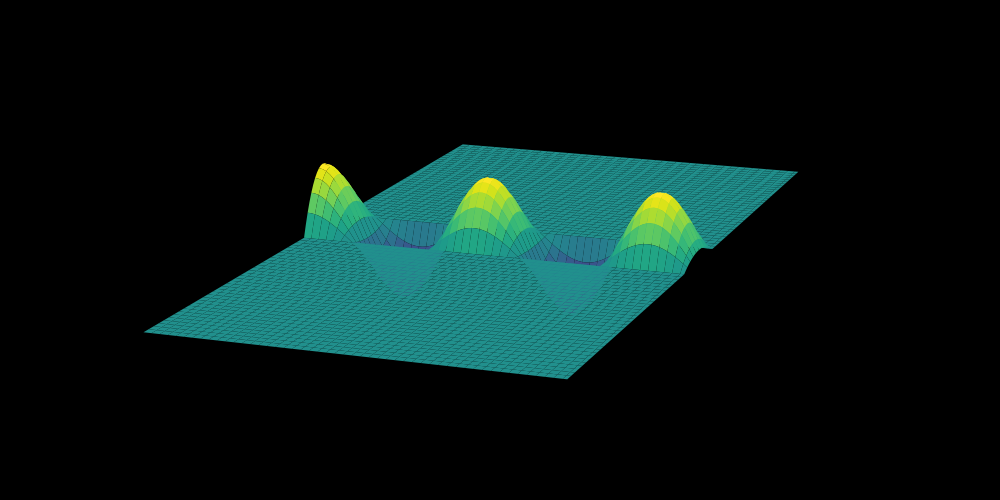

In [131]:
fig, ax, ys = plot_field_2d_surface(A, quadratic_piecewise2d,  zmax=4,
                     elev=15, azim=20, roll=0, z_lim_factor=1);

That method is good for well behaved functions.  But unbounded ones make the box_aspect badly skewed:

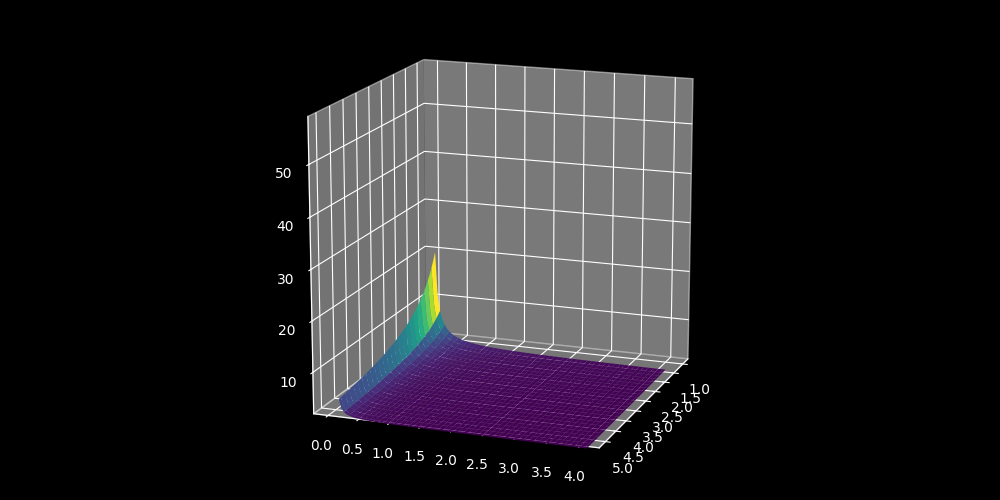

In [130]:
plot_field_2d_surface(A, lambda x,y:1/(x*y),  zmin=.05, zmax=4, xs=np.linspace(1, 5),
                     elev=15, azim=20, roll=0, product_func=False, zoom=1,
                     show_axis=True, z_lim_factor=3);

Seems like in that case we want to base the aspect only on the x-y extents of the data, then set the z_limits separately.  This is what we were doing before...

In [61]:
g = lambda x,y:1/(x*y)
g

/tmp/ipykernel_31015/2515277047.py:1: RuntimeWarning: divide by zero encountered in divide
  g = lambda x,y:1/(x*y)


ValueError: Axis limits -inf, inf cannot be infinite

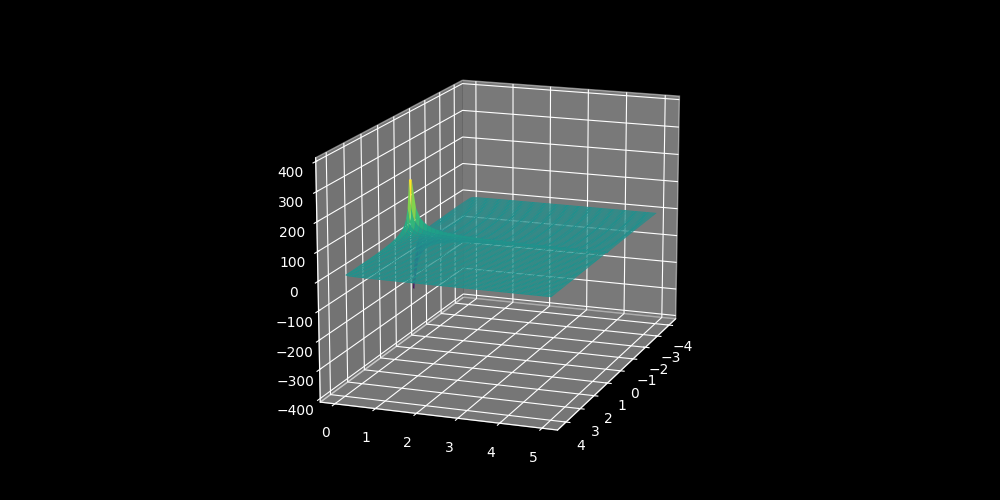

In [62]:
A.plot_field_2d_surface(g, 
                     elev=15, azim=20, roll=0, z_lim_factor=1, product_func=False, zoom=1,
                     show_axis=True);

In [102]:
~np.isinf(g(1, np.linspace(0,1,100)))

/tmp/ipykernel_31015/2515277047.py:1: RuntimeWarning: divide by zero encountered in divide
  g = lambda x,y:1/(x*y)


array([False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])